# Part 1 Question 1

In [15]:
# Load the data
import polars as pl

data_directory = "data/heart.csv"
data_split_file = "data/splits_heart.csv"

# add row_index column to heart data as it does not have it
# splits_heart.csv uses the row number (row_index)
data = pl.read_csv(data_directory).with_row_index("row_index")
splits = pl.read_csv(data_split_file).with_columns(
    pl.col("row_index").cast(pl.UInt32)
 )
# Attach the split label to every row
data_with_split = data.join(splits, on="row_index", how="left")

# Split into train and test
train_data = data_with_split.filter(pl.col("split") == "train").drop(["row_index", "split"])
test_data = data_with_split.filter(pl.col("split") == "test").drop(["row_index", "split"])


In [24]:
# types of features
print(train_data.describe())


shape: (9, 13)
┌────────────┬───────────┬──────┬─────────────┬───┬─────────────┬──────────┬──────────┬────────────┐
│ statistic  ┆ Age       ┆ Sex  ┆ ChestPainTy ┆ … ┆ ExerciseAng ┆ Oldpeak  ┆ ST_Slope ┆ HeartDisea │
│ ---        ┆ ---       ┆ ---  ┆ pe          ┆   ┆ ina         ┆ ---      ┆ ---      ┆ se         │
│ str        ┆ f64       ┆ str  ┆ ---         ┆   ┆ ---         ┆ f64      ┆ str      ┆ ---        │
│            ┆           ┆      ┆ str         ┆   ┆ str         ┆          ┆          ┆ f64        │
╞════════════╪═══════════╪══════╪═════════════╪═══╪═════════════╪══════════╪══════════╪════════════╡
│ count      ┆ 734.0     ┆ 734  ┆ 734         ┆ … ┆ 734         ┆ 734.0    ┆ 734      ┆ 734.0      │
│ null_count ┆ 0.0       ┆ 0    ┆ 0           ┆ … ┆ 0           ┆ 0.0      ┆ 0        ┆ 0.0        │
│ mean       ┆ 53.848774 ┆ null ┆ null        ┆ … ┆ null        ┆ 0.865123 ┆ null     ┆ 0.553134   │
│ std        ┆ 9.440574  ┆ null ┆ null        ┆ … ┆ null        ┆ 1.056964 ┆

In [25]:
#total number of missing values
missing_values = train_data.select(pl.all().null_count()).sum().to_dict()
total_missing_values = sum(missing_values.values())
print(f"total amount of missing values in train_data: {total_missing_values}")


total amount of missing values in train_data: shape: (1,)
Series: 'Age' [u32]
[
	0
]


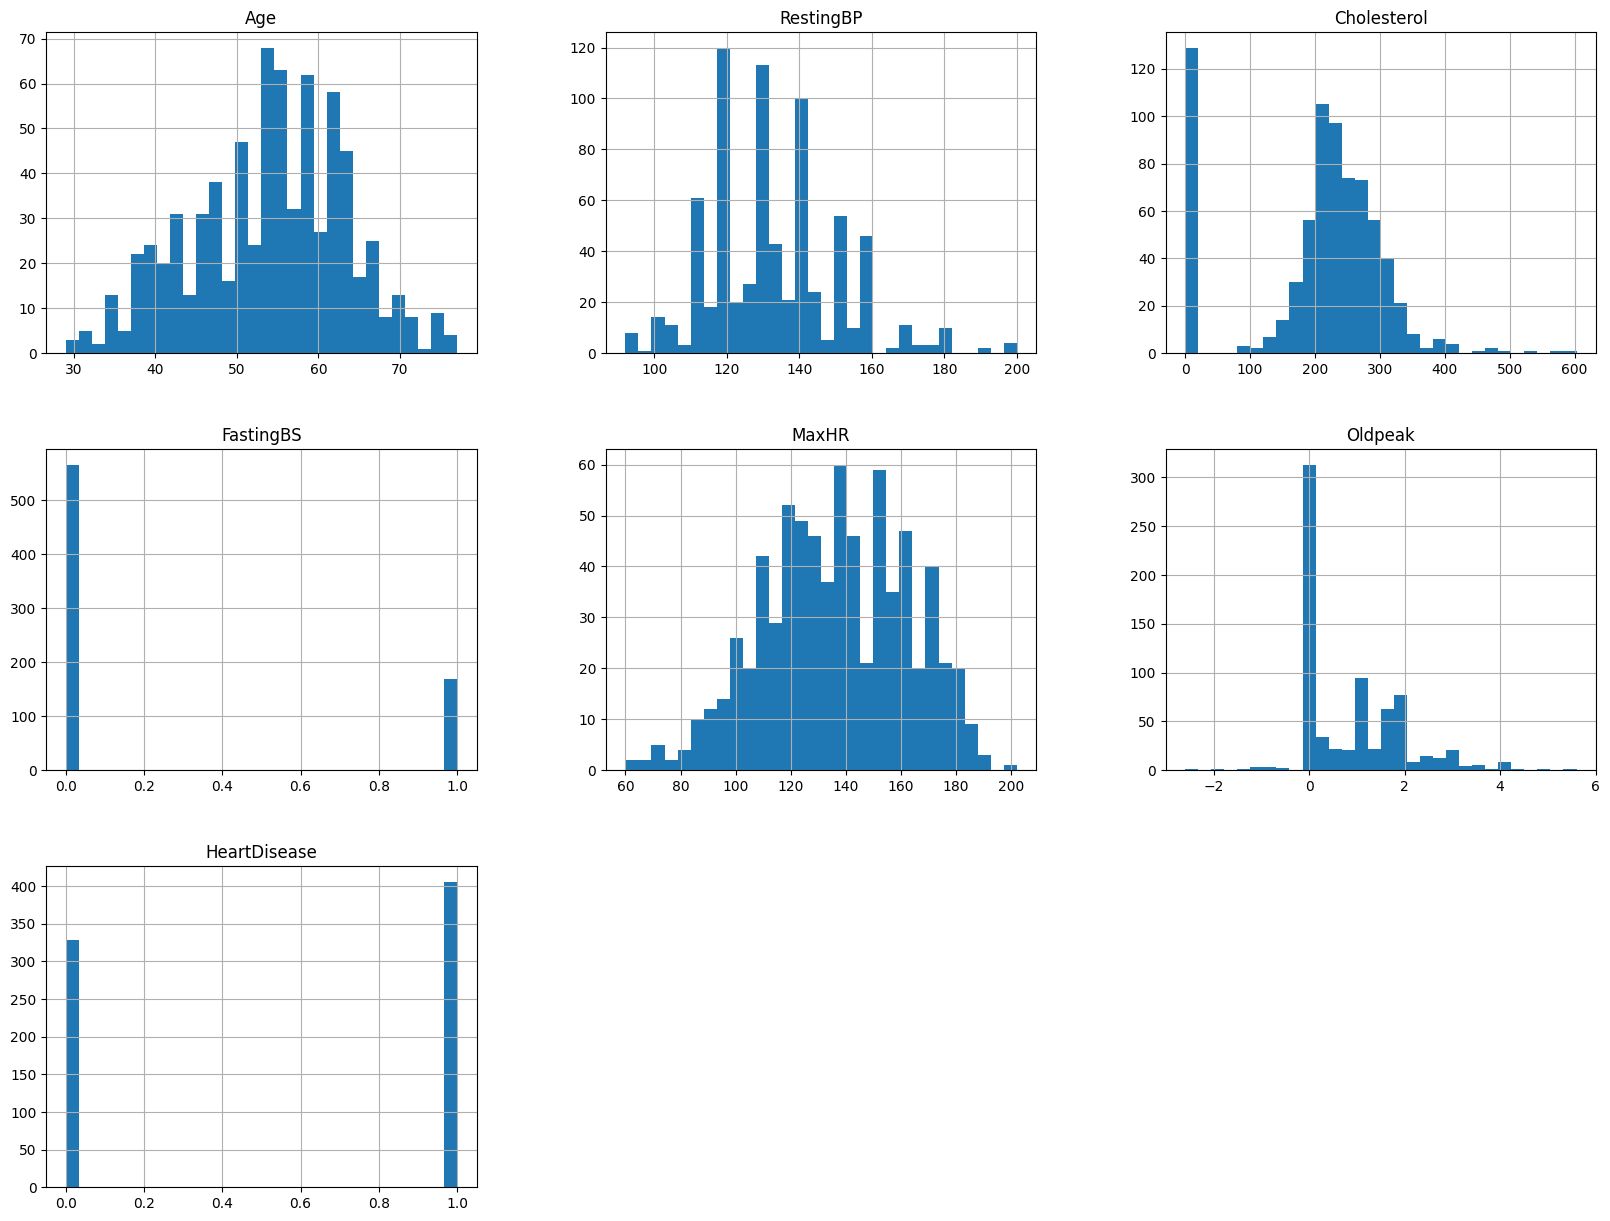

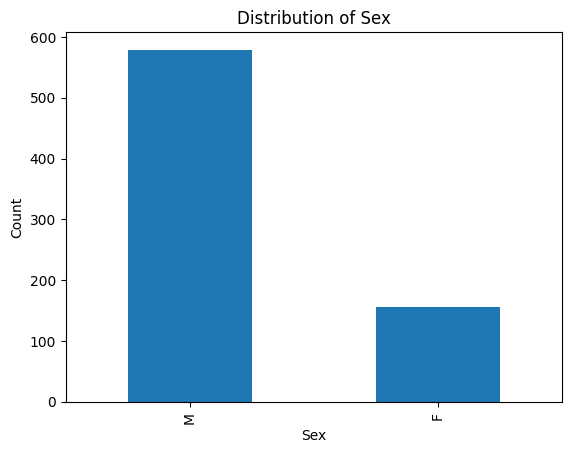

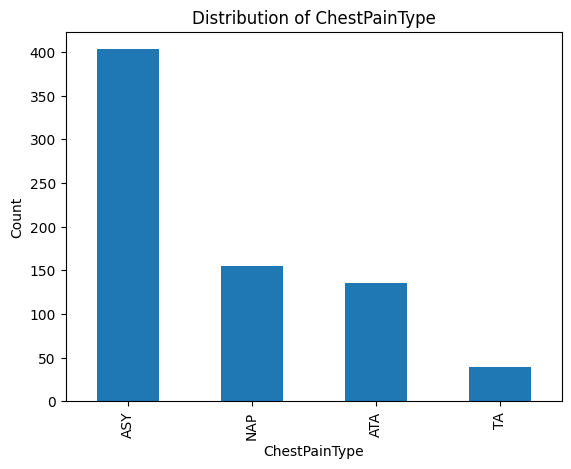

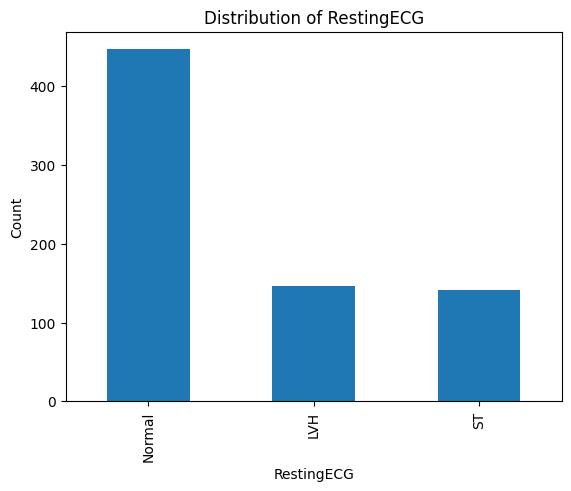

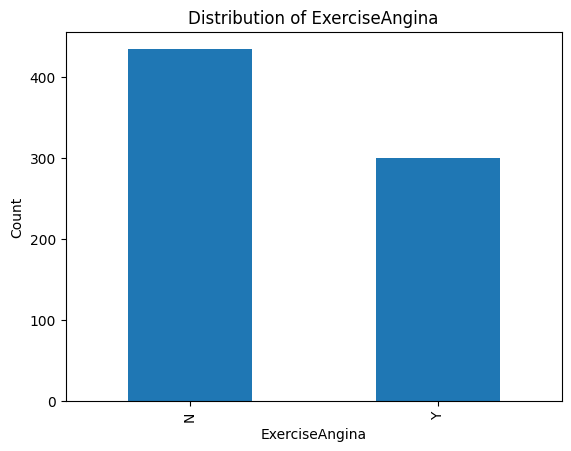

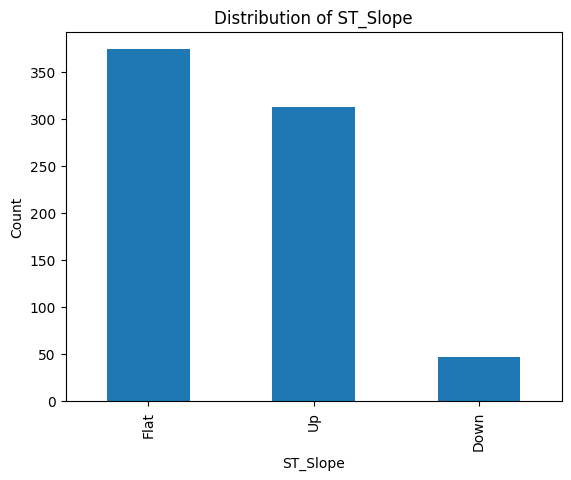

In [33]:
#distrubtion of the features
import matplotlib.pyplot as plt
import pandas as pd
train_data_df = train_data.to_pandas()
train_data_df.hist(bins=30, figsize=(20,15))
plt.show()
#bar charts for categorical features
categorical_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina","ST_Slope"]
for feature in categorical_features:
    train_data_df[feature].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

In [29]:
train_data

Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
i64,str,str,i64,i64,i64,str,i64,str,f64,str,i64
40,"""M""","""ATA""",140,289,0,"""Normal""",172,"""N""",0.0,"""Up""",0
48,"""F""","""ASY""",138,214,0,"""Normal""",108,"""Y""",1.5,"""Flat""",1
54,"""M""","""NAP""",150,195,0,"""Normal""",122,"""N""",0.0,"""Up""",0
39,"""M""","""NAP""",120,339,0,"""Normal""",170,"""N""",0.0,"""Up""",0
45,"""F""","""ATA""",130,237,0,"""Normal""",170,"""N""",0.0,"""Up""",0
…,…,…,…,…,…,…,…,…,…,…,…
59,"""M""","""ASY""",164,176,1,"""LVH""",90,"""N""",1.0,"""Flat""",1
45,"""M""","""TA""",110,264,0,"""Normal""",132,"""N""",1.2,"""Flat""",1
68,"""M""","""ASY""",144,193,1,"""Normal""",141,"""N""",3.4,"""Flat""",1
